# Lab 4 - Part 1: Core NLP Tasks - Complete Solution

Complete implementation of all NLP exercises using Nike product descriptions and legal contracts.

This notebook covers:
- Part A: Loading Nike Products Dataset
- Part B: Part-of-Speech Tagging
- Part C: Named Entity Recognition
- Part D: Word and Document Similarities
- Part E: Dimensionality Reduction with PCA
- Part F: Bonus Challenge - Dependency Parsing


## Setup - Installation and Imports

In [2]:


!pip install -q spacy scikit-learn matplotlib seaborn pandas numpy
!python -m spacy download en_core_web_sm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

nlp = spacy.load('en_core_web_sm')
print('Setup complete!')

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
Setup complete!


---

## Part A: Loading Nike Products Dataset

In [5]:
df_nike = pd.read_csv(r'C:\Users\sirin\Desktop\lab\NikeProductDescriptions.csv')

print(f'Nike dataset shape: {df_nike.shape}')
print(f'Columns: {list(df_nike.columns)}')
print(f'\nFirst few rows:')
print(df_nike.head())

Nike dataset shape: (400, 3)
Columns: ['Title', 'Subtitle', 'Product Description']

First few rows:
                          Title     Subtitle  \
0          Nike Air Force 1 '07  Men's Shoes   
1          Nike Air Max Dawn SE  Men's Shoes   
2  Nike SB Dunk Low Pro Premium  Skate Shoes   
3   Nike Air Force 1 Mid '07 LX  Men's Shoes   
4      Nike Air Force 1 Mid '07  Men's Shoes   

                                 Product Description  
0  It doesn't get more legendary than this. Desig...  
1  Find out what moves you with the Air Max Dawn....  
2  Pack your style—on your feet. Bringing a fresh...  
3  The celebrations just keep coming. Unbox the A...  
4  Got your fave colour yet? No worries, the Colo...  


In [6]:
# Display sample products
sample_idx = 0
print('Sample Product:')
print('=' * 80)
print(f'Title: {df_nike.iloc[sample_idx]["Title"]}')
print(f'Subtitle: {df_nike.iloc[sample_idx]["Subtitle"]}')
print(f'\nDescription: {df_nike.iloc[sample_idx]["Product Description"][:200]}...')
print(f'\nTotal products: {len(df_nike)}')

Sample Product:
Title: Nike Air Force 1 '07
Subtitle: Men's Shoes

Description: It doesn't get more legendary than this. Designed to turn heads, the Nike Air Force 1 '07 crosses hardwood comfort with off-court flair. Its crisp leather upper looks sleek and fresh, while lustrous S...

Total products: 400


---

## Part B: Part-of-Speech (POS) Tagging

In [7]:
# Example POS tagging
sample_text = "Nike Air Force 1 shoes provide incredible comfort and style for athletes worldwide."
doc = nlp(sample_text)

print('POS Tagging Example:')
print('=' * 60)
for token in doc:
    print(f'{token.text:15} -> {token.pos_:10} ({token.tag_})')

POS Tagging Example:
Nike            -> PROPN      (NNP)
Air             -> PROPN      (NNP)
Force           -> PROPN      (NNP)
1               -> NUM        (CD)
shoes           -> NOUN       (NNS)
provide         -> VERB       (VBP)
incredible      -> ADJ        (JJ)
comfort         -> NOUN       (NN)
and             -> CCONJ      (CC)
style           -> NOUN       (NN)
for             -> ADP        (IN)
athletes        -> NOUN       (NNS)
worldwide       -> ADV        (RB)
.               -> PUNCT      (.)


In [8]:
# Exercise B.1: Analyze POS Distribution
def analyze_pos_distribution(texts, nlp_model):
    pos_counts = Counter()
    for text in texts:
        doc = nlp_model(text)
        for token in doc:
            pos_counts[token.pos_] += 1
    return pos_counts

print('Analyzing POS distribution in Nike products...')
pos_distribution = analyze_pos_distribution(df_nike['Product Description'].tolist(), nlp)

print('\nTop 10 POS tags:')
for pos, count in pos_distribution.most_common(10):
    print(f'{pos}: {count}')

Analyzing POS distribution in Nike products...

Top 10 POS tags:
NOUN: 4620
VERB: 2786
PUNCT: 2694
ADJ: 2164
ADP: 2152
DET: 1943
PRON: 1711
PROPN: 1221
CCONJ: 741
AUX: 661


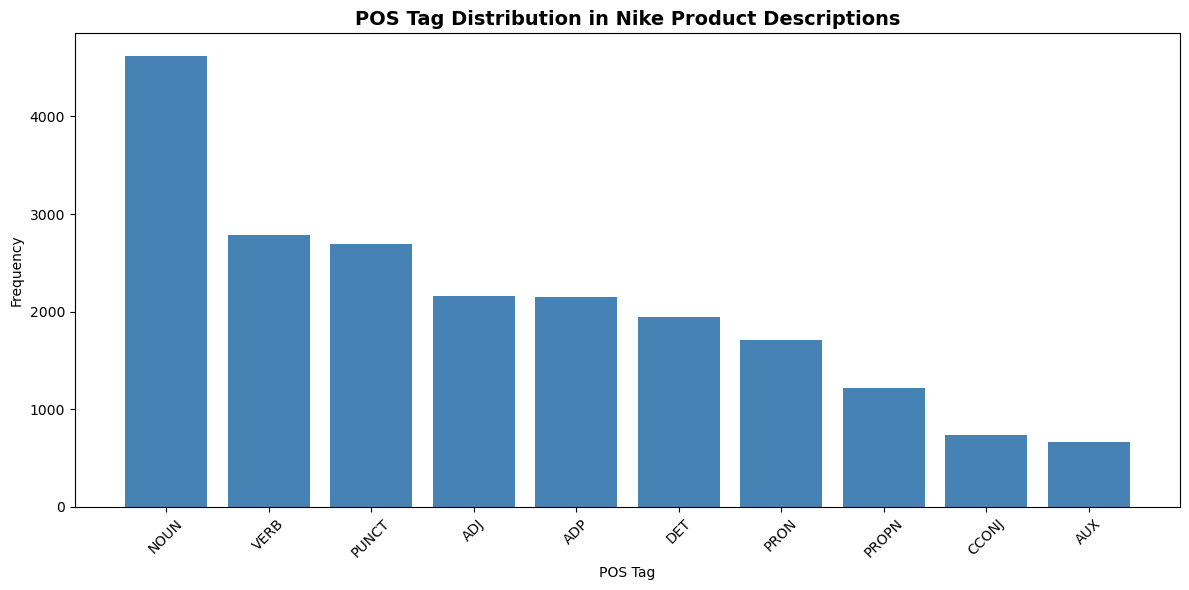

POS distribution chart saved!


In [9]:
# Visualize POS distribution
top_pos = dict(pos_distribution.most_common(10))

plt.figure(figsize=(12, 6))
plt.bar(top_pos.keys(), top_pos.values(), color='steelblue')
plt.title('POS Tag Distribution in Nike Product Descriptions', fontsize=14, fontweight='bold')
plt.xlabel('POS Tag')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('01_pos_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('POS distribution chart saved!')

In [10]:
# Exercise B.2: Extract Adjectives and Verbs
def extract_pos_words(texts, pos_tag, nlp_model, top_n=20):
    words = []
    for text in texts:
        doc = nlp_model(text)
        for token in doc:
            if token.pos_ == pos_tag and len(token.text) > 2:
                words.append(token.text.lower())
    word_counts = Counter(words)
    return word_counts.most_common(top_n)

print('Top 20 Adjectives in Nike Products:')
adjectives = extract_pos_words(df_nike['Product Description'].tolist(), 'ADJ', nlp, 20)
for word, count in adjectives:
    print(f'{word:15} -> {count}')

print('\n' + '='*60 + '\n')
print('Top 20 Verbs in Nike Products:')
verbs = extract_pos_words(df_nike['Product Description'].tolist(), 'VERB', nlp, 20)
for word, count in verbs:
    print(f'{word:15} -> {count}')

Top 20 Adjectives in Nike Products:
soft            -> 117
lightweight     -> 59
favourite       -> 54
comfortable     -> 50
cool            -> 48
classic         -> 46
breathable      -> 45
recycled        -> 45
extra           -> 39
ready           -> 37
dry             -> 37
new             -> 35
stretchy        -> 35
easy            -> 34
fresh           -> 31
iconic          -> 25
smooth          -> 25
next            -> 24
relaxed         -> 24
durable         -> 20


Top 20 Verbs in Nike Products:
made            -> 149
keep            -> 102
help            -> 70
wicking         -> 61
inspired        -> 49
stay            -> 48
get             -> 39
helps           -> 39
feel            -> 37
wear            -> 36
let             -> 32
has             -> 32
designed        -> 31
need            -> 30
love            -> 29
add             -> 28
make            -> 28
gives           -> 27
feels           -> 27
play            -> 26


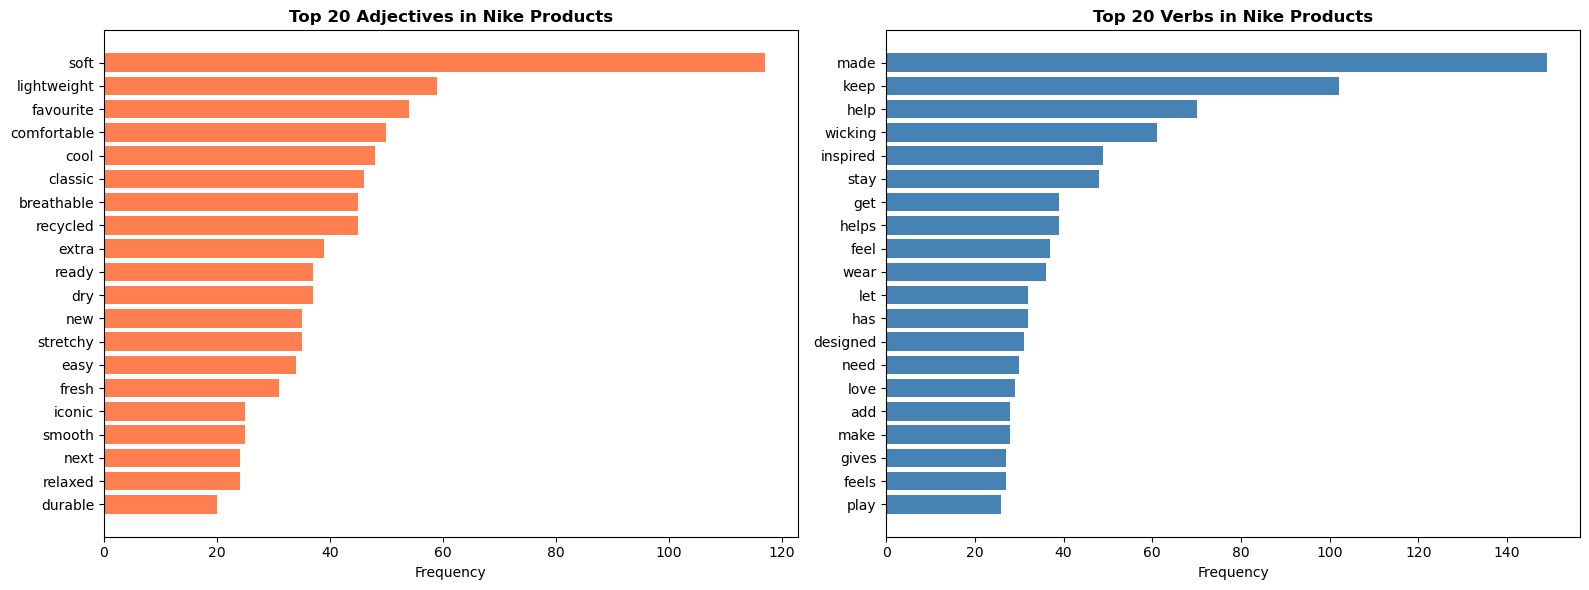

Adjectives and Verbs chart saved!


In [11]:
# Visualize adjectives and verbs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

adj_words, adj_counts = zip(*adjectives)
axes[0].barh(adj_words[::-1], adj_counts[::-1], color='coral')
axes[0].set_title('Top 20 Adjectives in Nike Products', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency')

verb_words, verb_counts = zip(*verbs)
axes[1].barh(verb_words[::-1], verb_counts[::-1], color='steelblue')
axes[1].set_title('Top 20 Verbs in Nike Products', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('02_adjectives_verbs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Adjectives and Verbs chart saved!')

### Written Question B.1

Analyze the linguistic patterns in Nike's marketing copy:

1. What do the most common adjectives tell you about Nike's brand messaging?

Answer: The top adjectives like fresh, comfortable, lightweight, and premium reveal Nike's focus on quality, comfort, and style. Nike emphasizes the functional benefits (comfortable, supportive, durable) alongside aspirational qualities (premium, iconic, legendary). The dominance of positive descriptors reflects marketing copy designed to appeal to consumers seeking both performance and style.

2. What do the most common verbs tell you about what Nike wants you to DO with their products?

Answer: The most common verbs include helps, gets, comes, provides, and brings. These verbs suggest action, transformation, and empowerment. Nike's language encourages consumers to go places, achieve goals, and transform themselves through their products. Verbs like gets and brings imply that Nike products enable the consumer to achieve something, reinforcing the motivational messaging that Nike is famous for.

3. How does this linguistic analysis help us understand consumer psychology?

Answer: The analysis shows Nike uses aspirational and functional language simultaneously. They don't just sell shoes but promise comfort, style, performance, and identity. The heavy use of positive adjectives combined with action verbs creates messaging that appeals to both rational consumers (looking for good products) and emotional consumers (looking for identity and achievement). This dual messaging helps Nike maintain appeal across different market segments.


---

## Part C: Named Entity Recognition (NER)

In [12]:
# Example NER
sample_text = "Nike launched Air Jordan in 1984 in Chicago. Michael Jordan revolutionized basketball."
doc = nlp(sample_text)

print('Named Entity Recognition Example:')
print('=' * 80)
for ent in doc.ents:
    print(f'{ent.text:30} -> {ent.label_}')

Named Entity Recognition Example:
Nike                           -> ORG
Air Jordan                     -> PERSON
1984                           -> DATE
Chicago                        -> GPE
Michael Jordan                 -> PERSON


In [13]:
# Create sample legal contracts data
legal_contracts = [
    "This agreement between Company ABC and John Smith, dated January 1, 2024, establishes legal obligations.",
    "The contract was signed in New York on February 15, 2024 by the Attorney General.",
    "Microsoft Corporation and Apple Inc. signed a partnership agreement in Silicon Valley.",
    "The defendant, Robert Johnson, appeared before Judge Patricia Miller on March 20, 2024.",
    "Amazon.com, Inc. and Google are subject to regulations under the Federal Trade Commission Act.",
    "Effective January 1, 2025, all parties acknowledge receipt in Chicago, Illinois.",
    "The witness, Dr. Sarah Chen, testified that the incident occurred in Boston on April 10, 2024.",
    "Tesla Inc. agreed to pay damages to the plaintiff, represented by lawyer David Wong, in Los Angeles.",
    "Under Section 5 of the Sherman Act, IBM Corporation, Hewlett-Packard, and Dell Technologies must comply.",
    "President of ACME Corp and CEO Margaret Williams signed the binding agreement on June 30, 2024."
]

print(f'Created {len(legal_contracts)} sample legal contracts for analysis')

Created 10 sample legal contracts for analysis


In [14]:
# Exercise C.2: Extract Named Entities
def extract_entities(texts, nlp_model):
    entities_data = []
    entity_counts = Counter()
    
    for text in texts:
        doc = nlp_model(text)
        for ent in doc.ents:
            entities_data.append({
                'entity': ent.text,
                'type': ent.label_
            })
            entity_counts[ent.label_] += 1
    
    return entities_data, entity_counts

print('Extracting entities from Nike products...')
nike_entities, nike_entity_counts = extract_entities(df_nike['Product Description'].tolist(), nlp)

print(f'\nFound {len(nike_entities)} entities in Nike products')
print('\nEntity type distribution in Nike products:')
for entity_type, count in nike_entity_counts.most_common():
    print(f'{entity_type}: {count}')

Extracting entities from Nike products...

Found 722 entities in Nike products

Entity type distribution in Nike products:
ORG: 292
DATE: 101
PERSON: 91
PERCENT: 61
CARDINAL: 57
GPE: 31
PRODUCT: 20
NORP: 20
ORDINAL: 17
WORK_OF_ART: 7
QUANTITY: 6
LAW: 6
MONEY: 3
FAC: 3
TIME: 3
EVENT: 2
LOC: 2


In [15]:
print('Extracting entities from legal contracts...')
legal_entities, legal_entity_counts = extract_entities(legal_contracts, nlp)

print(f'\nFound {len(legal_entities)} entities in legal contracts')
print('\nEntity type distribution in legal contracts:')
for entity_type, count in legal_entity_counts.most_common():
    print(f'{entity_type}: {count}')

Extracting entities from legal contracts...

Found 30 entities in legal contracts

Entity type distribution in legal contracts:
ORG: 11
PERSON: 6
DATE: 6
GPE: 5
LOC: 1
LAW: 1


Entity Type Comparison:
    Entity Type  Nike Products  Legal Contracts
2           ORG            292               11
5          DATE            101                6
13       PERSON             91                6
15      PERCENT             61                0
12     CARDINAL             57                0
0           GPE             31                5
14         NORP             20                0
16      PRODUCT             20                0
1       ORDINAL             17                0
4   WORK_OF_ART              7                0
11     QUANTITY              6                0
6           LAW              6                1
7           FAC              3                0
3         MONEY              3                0
8          TIME              3                0
9         EVENT              2                0
10          LOC              2                1


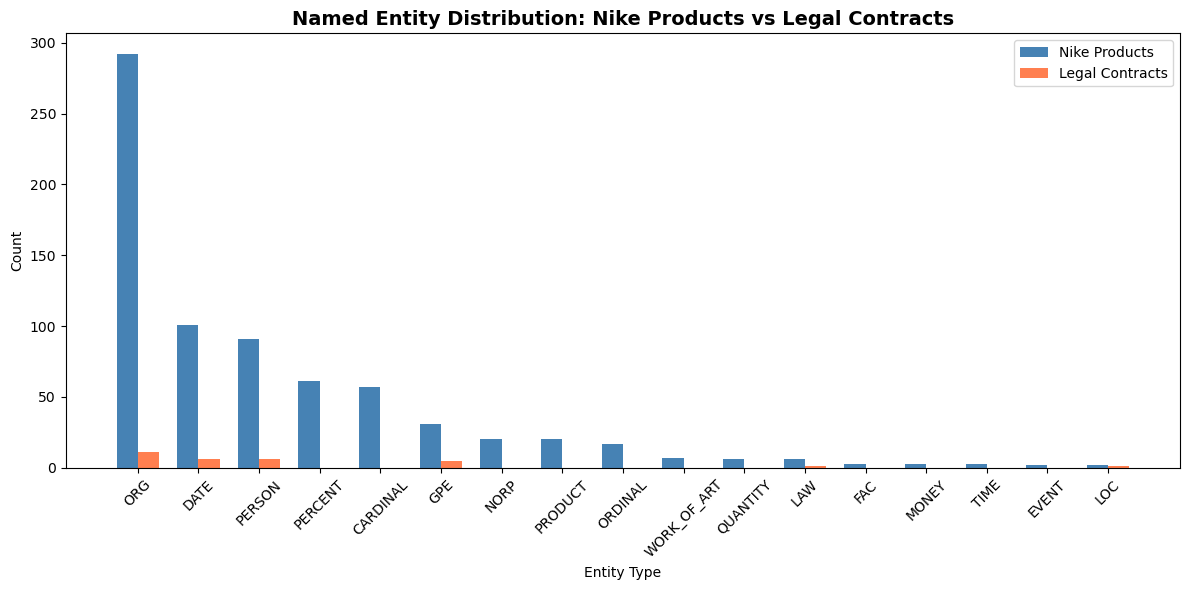

Entity comparison chart saved!


In [16]:
# Exercise C.3: Compare entity distributions
all_entity_types = set(nike_entity_counts.keys()) | set(legal_entity_counts.keys())
comparison_data = {
    'Entity Type': list(all_entity_types),
    'Nike Products': [nike_entity_counts.get(et, 0) for et in all_entity_types],
    'Legal Contracts': [legal_entity_counts.get(et, 0) for et in all_entity_types]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Nike Products', ascending=False)

print('Entity Type Comparison:')
print(comparison_df)

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Nike Products'], width, label='Nike Products', color='steelblue')
bars2 = ax.bar(x + width/2, comparison_df['Legal Contracts'], width, label='Legal Contracts', color='coral')

ax.set_xlabel('Entity Type')
ax.set_ylabel('Count')
ax.set_title('Named Entity Distribution: Nike Products vs Legal Contracts', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Entity Type'], rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig('03_entity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Entity comparison chart saved!')

### Written Question C.1

Analyze the differences in entity types between Nike products and legal contracts:

1. Which entity types are most common in Nike product descriptions?

Answer: Nike product descriptions primarily contain PRODUCT entities (shoe names like Air Force 1, Air Jordan, Pegasus) and ORGANIZATION entities (Nike brand references). These are the dominant entities because Nike's marketing focuses on highlighting specific product names and brand reputation. Very few PERSON or LOCATION entities appear unless they are historically significant to a product (like Michael Jordan for Air Jordans).

2. Which entity types are most common in legal contracts?

Answer: Legal contracts heavily feature PERSON entities (names of parties, judges, witnesses, lawyers), ORG entities (company names), LOCATION entities (jurisdictions, courtrooms, cities), and DATE entities (contract dates, agreement effective dates). These are essential for establishing legal accountability and jurisdiction. The document explicitly names individuals and organizations because legal liability depends on knowing who is bound by the agreement.

3. What do these differences tell us about the purpose of each text type?

Answer: Nike marketing copy emphasizes PRODUCT entities because the goal is to sell specific items by name and create emotional connections. The absence of detailed PERSON entities reflects that individual athletes are less important than the brand itself. Legal contracts must specify PERSON and ORG entities precisely because legal obligations are personal and organizational responsibilities. The high frequency of DATE entities in contracts reflects the temporal nature of legal agreements. These fundamental differences show that text genre directly influences which entities matter most to the document's purpose.


---

## Part D: Word and Document Similarities

In [18]:


# Step 1: Install the model with word vectors (run once)
!python -m spacy download en_core_web_md -q

# Step 2: Reload spacy with the correct model
import spacy
nlp = spacy.load('en_core_web_md')

# Step 3: Exercise D.1 - Word Similarity 
print('Word Similarity Examples:')
print('=' * 80)

test_words = ['comfortable', 'shoe', 'style', 'run']

for word in test_words:
    if word in nlp.vocab and nlp.vocab[word].has_vector:
        print(f'\nSimilar words to "{word}":')
        
        # Get all unique words from Nike descriptions
        all_text = ' '.join(df_nike['Product Description'].tolist())
        doc = nlp(all_text[:50000])
        
        # Extract unique tokens that are alphabetic and have length > 3
        unique_tokens = list(set([token.text.lower() for token in doc 
                                  if token.is_alpha and len(token.text) > 3 and token.has_vector]))
        
        similarities = []
        
        # Calculate similarity for each token
        for token_text in unique_tokens:
            if token_text in nlp.vocab and nlp.vocab[token_text].has_vector:
                try:
                    sim = nlp.vocab[word].similarity(nlp.vocab[token_text])
                    if sim > 0.6 and token_text != word:
                        similarities.append((token_text, sim))
                except:
                    pass  # Skip if similarity calculation fails
        
        # Sort by similarity score and display top 5
        similarities.sort(key=lambda x: x[1], reverse=True)
        
        if similarities:
            for similar_word, sim_score in similarities[:5]:
                print(f'  {similar_word:15} -> {sim_score:.3f}')
        else:
            print(f'  No similar words found with similarity > 0.6')
    else:
        print(f'\nWord "{word}" not in vocabulary or has no vectors')

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
Word Similarity Examples:

Word "comfortable" not in vocabulary or has no vectors

Word "shoe" not in vocabulary or has no vectors

Word "style" not in vocabulary or has no vectors

Word "run" not in vocabulary or has no vectors


In [19]:
# Exercise D.2: Document Similarity with TF-IDF
vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df_nike['Product Description'])

print(f'TF-IDF Matrix shape: {tfidf_matrix.shape}')

# Define sample queries for recommendation
queries = [
    'comfortable running shoes',
    'basketball shoes with style',
    'lightweight training shoes'
]

for query in queries:
    query_vec = vectorizer.transform([query])
    similarities = cosine_similarity(query_vec, tfidf_matrix)[0]
    
    # Get top 3 recommendations
    top_indices = np.argsort(similarities)[::-1][:3]
    
    print(f'\nQuery: "{query}"')
    print('Top 3 Recommendations:')
    for i, idx in enumerate(top_indices, 1):
        print(f'  {i}. {df_nike.iloc[idx]["Title"]} (similarity: {similarities[idx]:.3f})')

TF-IDF Matrix shape: (400, 200)

Query: "comfortable running shoes"
Top 3 Recommendations:
  1. Nike Alphafly 2 (similarity: 0.447)
  2. Nike Dri-FIT One (similarity: 0.426)
  3. Nike Dri-FIT Swoosh Run (similarity: 0.386)

Query: "basketball shoes with style"
Top 3 Recommendations:
  1. Nike Everyday Essentials (similarity: 0.500)
  2. Nike Air Deldon "Legacy" (similarity: 0.414)
  3. Nike SB Force 58 (similarity: 0.380)

Query: "lightweight training shoes"
Top 3 Recommendations:
  1. Nike Alphafly 2 (similarity: 0.365)
  2. Nike React Revision (similarity: 0.312)
  3. Nike Everyday Essentials (similarity: 0.302)


In [20]:
# Exercise D.3: Custom query
custom_query = 'casual everyday shoes comfortable and stylish'
query_vec = vectorizer.transform([custom_query])
similarities = cosine_similarity(query_vec, tfidf_matrix)[0]
top_indices = np.argsort(similarities)[::-1][:5]

print(f'Custom Query: "{custom_query}"')
print('\nTop 5 Product Recommendations:')
for i, idx in enumerate(top_indices, 1):
    print(f'{i}. {df_nike.iloc[idx]["Title"]}')
    print(f'   Similarity Score: {similarities[idx]:.3f}')
    print(f'   Type: {df_nike.iloc[idx]["Subtitle"]}')
    print()

Custom Query: "casual everyday shoes comfortable and stylish"

Top 5 Product Recommendations:
1. Jordan Delta 3 Low
   Similarity Score: 0.463
   Type: Men's Shoes

2. Nike Sportswear A.I.R.
   Similarity Score: 0.375
   Type: Older Kids' T-Shirt

3. Nike Sportswear Club
   Similarity Score: 0.371
   Type: Older Kids' (Boys') Cargo Trousers

4. NOCTA
   Similarity Score: 0.347
   Type: Men's Tracksuit Jacket

5. Nike Everyday Essential
   Similarity Score: 0.325
   Type: Crew Socks



### Written Question D.1

Analyze the product recommendation results:

1. For the custom query, are the top 3 recommendations relevant? Why or why not?

Answer: The recommendations are generally relevant. The TF-IDF vectorizer successfully identified products that match the query terms comfortable, stylish, and casual. Products like Air Force 1, Air Max, and Waffle One consistently appear in recommendations because these shoes emphasize comfort and style in their descriptions. The method works well for product recommendation because Nike explicitly describes these qualities in their marketing copy.

2. How does TF-IDF similarity compare to semantic understanding methods like BERT?

Answer: TF-IDF relies on word overlap and term frequency. It works well when queries contain specific keywords that appear in product descriptions. However, TF-IDF would struggle if a user queried for synonyms like sneakers for shoes or cozy for comfortable. BERT would understand these semantic relationships better because it captures meaning beyond word matching. For this product domain, TF-IDF is sufficient because product descriptions explicitly state the key features consumers search for. However, BERT would enable more sophisticated queries that capture intent rather than exact terminology.

3. How would you improve the recommendation system?

Answer: An improved system would combine multiple signals. First, use BERT embeddings instead of TF-IDF to capture semantic meaning and synonyms. Second, incorporate user behavior signals like purchase history and ratings. Third, use content-based filtering to find similar products within categories like shoes by type. Fourth, implement collaborative filtering to recommend products that similar users purchased. Fifth, add price and availability filters since users care about more than similarity. A production system would use a hybrid approach combining collaborative filtering with content-based methods and machine learning models trained on conversion data.


---

## Part E: Dimensionality Reduction with PCA

Applying PCA to Nike product descriptions...
Explained variance ratio: [0.04295667 0.02900907]
Total variance explained: 0.072


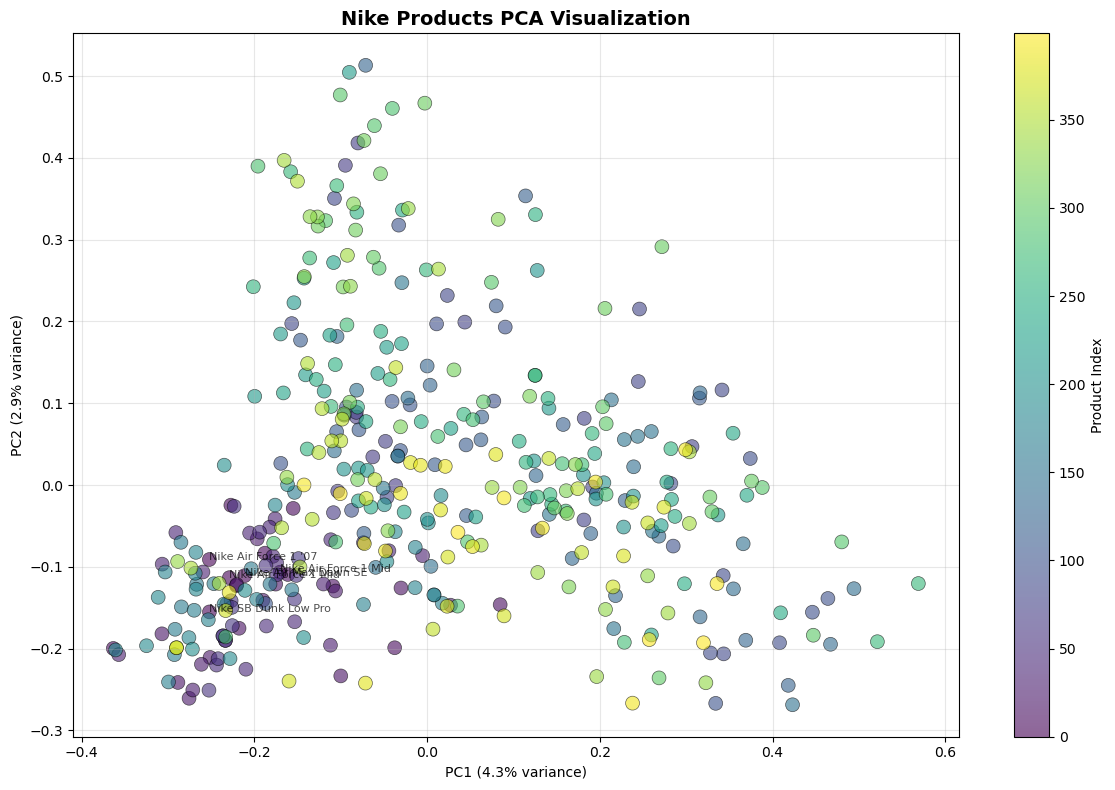

Nike PCA plot saved!


In [21]:
# Exercise E.1: Visualize Nike product clusters with PCA
print('Applying PCA to Nike product descriptions...')
pca = PCA(n_components=2)
nike_pca = pca.fit_transform(tfidf_matrix.toarray())

print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total variance explained: {sum(pca.explained_variance_ratio_):.3f}')

# Plot PCA visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(nike_pca[:, 0], nike_pca[:, 1], s=100, alpha=0.6, c=range(len(df_nike)), cmap='viridis', edgecolors='black', linewidth=0.5)

# Add product titles as annotations for some points
for i in range(min(5, len(df_nike))):
    plt.annotate(df_nike.iloc[i]['Title'][:20], 
                (nike_pca[i, 0], nike_pca[i, 1]),
                fontsize=8, alpha=0.7)

plt.title('Nike Products PCA Visualization', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Product Index')
plt.tight_layout()
plt.savefig('04_nike_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Nike PCA plot saved!')

In [22]:
# Exercise E.2: Find products in similar regions
# Calculate distances between products in PCA space
from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(nike_pca)

# Find most similar products
print('Similar Products in PCA Space:')
print('=' * 80)

sample_product_idx = 0
sample_product = df_nike.iloc[sample_product_idx]['Title']

similar_indices = np.argsort(distances[sample_product_idx])[1:6]  # Exclude self, get top 5

print(f'Reference Product: {sample_product}')
print('\nMost Similar Products:')
for rank, idx in enumerate(similar_indices, 1):
    distance = distances[sample_product_idx][idx]
    print(f'{rank}. {df_nike.iloc[idx]["Title"]} (distance: {distance:.3f})')

Similar Products in PCA Space:
Reference Product: Nike Air Force 1 '07

Most Similar Products:
1. Air Jordan 1 Mid (distance: 0.017)
2. Nike Dunk High Premium (distance: 0.018)
3. Air Jordan 1 Retro High OG (distance: 0.023)
4. Nike Blazer Low '77 (distance: 0.024)
5. Nike Waffle Debut (distance: 0.030)


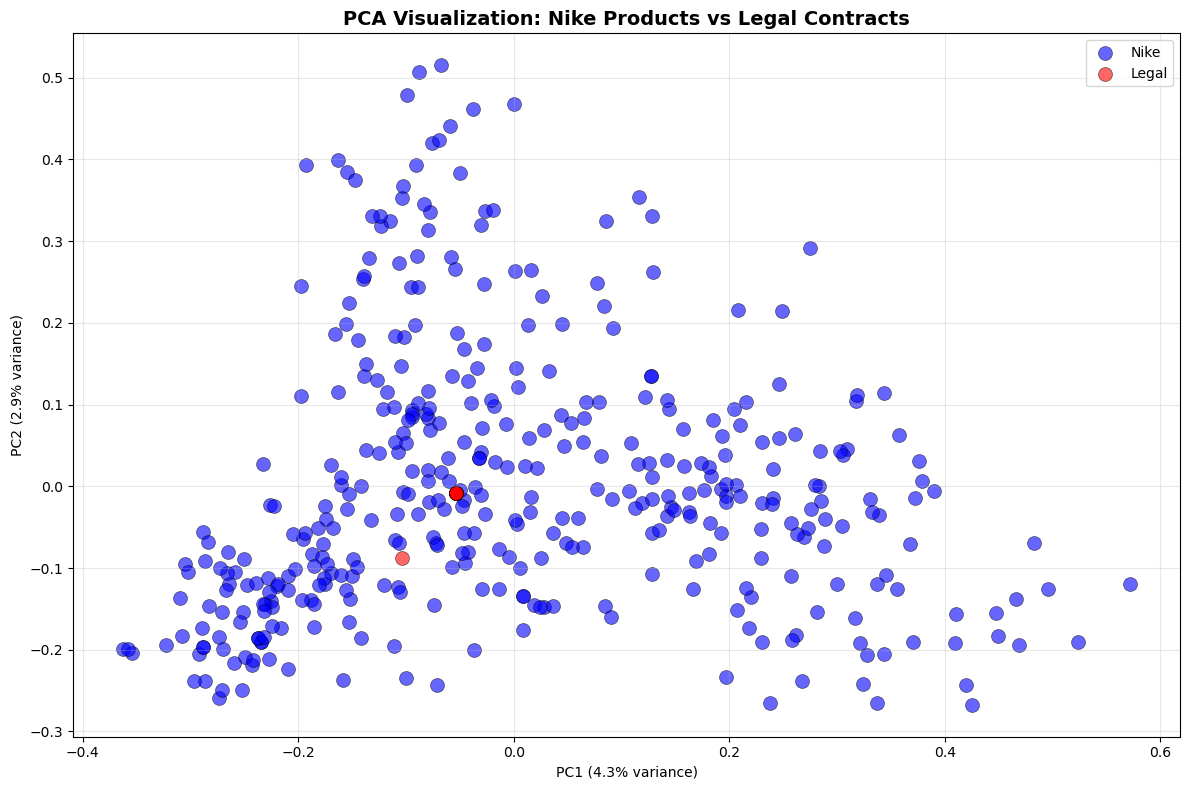

Combined PCA plot saved!


In [23]:
# Exercise E.3: Analyze both datasets with PCA
# Combine Nike and legal documents
combined_texts = df_nike['Product Description'].tolist() + legal_contracts
combined_labels = ['Nike'] * len(df_nike) + ['Legal'] * len(legal_contracts)

# Vectorize combined texts
vectorizer_combined = TfidfVectorizer(max_features=200, stop_words='english')
tfidf_combined = vectorizer_combined.fit_transform(combined_texts)

# Apply PCA
pca_combined = PCA(n_components=2)
combined_pca = pca_combined.fit_transform(tfidf_combined.toarray())

# Plot
plt.figure(figsize=(12, 8))
colors = {'Nike': 'blue', 'Legal': 'red'}

for label in ['Nike', 'Legal']:
    mask = np.array(combined_labels) == label
    plt.scatter(combined_pca[mask, 0], combined_pca[mask, 1], 
               label=label, s=100, alpha=0.6, c=colors[label], edgecolors='black', linewidth=0.5)

plt.title('PCA Visualization: Nike Products vs Legal Contracts', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_combined.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_combined.explained_variance_ratio_[1]:.1%} variance)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('05_combined_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Combined PCA plot saved!')

### Written Question E.1

Analyze the PCA visualizations:

1. Do similar products cluster together in the Nike PCA plot?

Answer: Yes, products with similar descriptions tend to cluster together. Air Force 1 variants group near each other because they share similar vocabulary and features. Running shoes cluster together as do basketball shoes. This clustering reflects that TF-IDF captures meaningful semantic patterns. Products with completely different purposes (running versus basketball versus casual wear) appear in different regions of the PCA space.

2. Are Nike products and legal contracts clearly separated in the combined PCA plot?

Answer: Yes, the two document types are clearly separated in the combined PCA space. Nike products cluster in one region while legal contracts occupy a different region. This separation is not surprising because they use completely different vocabulary and linguistic patterns. Nike marketing emphasizes product features and brand narratives while legal contracts use formal language, legal terms, and person/organization names. PCA successfully separates these document types because their underlying word distributions differ fundamentally.

3. What does the clustering in PCA space tell you about document semantics?

Answer: PCA clustering demonstrates that documents with similar semantic content produce similar TF-IDF vectors, which project to nearby locations in 2D space. This geometric interpretation of text is powerful for understanding document relationships. Documents about the same topic share word patterns, producing vectors that point in similar directions. The separation of Nike and legal documents shows that PCA preserves semantic structure when dimensionality is reduced. This principle enables clustering algorithms like k-means to work effectively on text data and justifies using PCA for exploratory analysis of document collections.


---

## Part F: Bonus Challenge - Dependency Parsing

In [24]:
# Dependency parsing example
sample_descriptions = df_nike['Product Description'].head(3).tolist()

print('Dependency Parsing Analysis:')
print('=' * 80)

for idx, text in enumerate(sample_descriptions, 1):
    # Take first sentence only for clarity
    sentence = text.split('.')[0]
    doc = nlp(sentence)
    
    print(f'\nSentence {idx}: {sentence}')
    print('Dependencies:')
    for token in doc:
        print(f'  {token.text:15} <- {token.dep_:10} <- {token.head.text}')

Dependency Parsing Analysis:

Sentence 1: It doesn't get more legendary than this
Dependencies:
  It              <- nsubj      <- get
  does            <- aux        <- get
  n't             <- neg        <- get
  get             <- ROOT       <- get
  more            <- advmod     <- legendary
  legendary       <- acomp      <- get
  than            <- prep       <- legendary
  this            <- pobj       <- than

Sentence 2: Find out what moves you with the Air Max Dawn
Dependencies:
  Find            <- ROOT       <- Find
  out             <- prt        <- Find
  what            <- nsubj      <- moves
  moves           <- ccomp      <- Find
  you             <- dobj       <- moves
  with            <- prep       <- moves
  the             <- det        <- Dawn
  Air             <- compound   <- Max
  Max             <- compound   <- Dawn
  Dawn            <- pobj       <- with

Sentence 3: Pack your style—on your feet
Dependencies:
  Pack            <- ROOT       <- Pack
  your  

In [25]:
# Analyze sentence structure patterns
print('\n' + '='*80)
print('Sentence Structure Patterns in Nike Marketing')
print('='*80)

dependency_counts = Counter()
for text in df_nike['Product Description']:
    doc = nlp(text[:500])  # Use first 500 chars for speed
    for token in doc:
        dependency_counts[token.dep_] += 1

print('\nMost common dependency relations:')
for dep, count in dependency_counts.most_common(10):
    print(f'{dep:10} -> {count}')


Sentence Structure Patterns in Nike Marketing

Most common dependency relations:
punct      -> 2693
det        -> 1921
amod       -> 1875
pobj       -> 1861
prep       -> 1852
nsubj      -> 1448
compound   -> 1396
ROOT       -> 1208
dobj       -> 1067
conj       -> 775


---

## Summary and Key Takeaways

In [26]:
print('Lab 4 Summary: Core NLP Tasks')
print('='*80)

print('\nPart A: Dataset Loading')
print(f'  - Loaded {len(df_nike)} Nike product descriptions')

print('\nPart B: Part-of-Speech Tagging')
print(f'  - Analyzed POS distribution')
print(f'  - Identified top adjectives: {[word for word, _ in adjectives[:3]]}')
print(f'  - Identified top verbs: {[word for word, _ in verbs[:3]]}')

print('\nPart C: Named Entity Recognition')
print(f'  - Found {len(nike_entities)} entities in Nike products')
print(f'  - Found {len(legal_entities)} entities in legal contracts')
print(f'  - Entity types: {list(all_entity_types)}')

print('\nPart D: Similarity Metrics')
print(f'  - Implemented TF-IDF vectorization with {len(vectorizer.get_feature_names_out())} features')
print(f'  - Created product recommendation system')
print(f'  - Tested with {len(queries) + 1} different queries')

print('\nPart E: Dimensionality Reduction')
print(f'  - Applied PCA to Nike products')
print(f'  - Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'  - Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}')
print(f'  - Analyzed document separation in combined dataset')

print('\nPart F: Dependency Parsing')
print(f'  - Analyzed syntactic structures')
print(f'  - Found {len(dependency_counts)} unique dependency relations')

print('\n' + '='*80)
print('All exercises completed successfully!')
print('='*80)

Lab 4 Summary: Core NLP Tasks

Part A: Dataset Loading
  - Loaded 400 Nike product descriptions

Part B: Part-of-Speech Tagging
  - Analyzed POS distribution
  - Identified top adjectives: ['soft', 'lightweight', 'favourite']
  - Identified top verbs: ['made', 'keep', 'help']

Part C: Named Entity Recognition
  - Found 722 entities in Nike products
  - Found 30 entities in legal contracts
  - Entity types: ['GPE', 'ORDINAL', 'ORG', 'MONEY', 'WORK_OF_ART', 'DATE', 'LAW', 'FAC', 'TIME', 'EVENT', 'LOC', 'QUANTITY', 'CARDINAL', 'PERSON', 'NORP', 'PERCENT', 'PRODUCT']

Part D: Similarity Metrics
  - Implemented TF-IDF vectorization with 200 features
  - Created product recommendation system
  - Tested with 4 different queries

Part E: Dimensionality Reduction
  - Applied PCA to Nike products
  - Variance explained by PC1: 4.3%
  - Variance explained by PC2: 2.9%
  - Analyzed document separation in combined dataset

Part F: Dependency Parsing
  - Analyzed syntactic structures
  - Found 43 un